- Image
   ↓
- Patch Split
   ↓
- Flatten
   ↓
- Linear Embedding
   ↓
- Add CLS Token
   ↓
- Add Positional Encoding
   ↓
- Transformer Encoder Stack
   ↓
- Take CLS Token
   ↓
- MLP Head
   ↓
- Prediction

In [2]:
from PIL import Image
import torch
import torchvision.transforms as transforms

In [3]:
img = Image.open("GOT.jpg").convert("RGB")

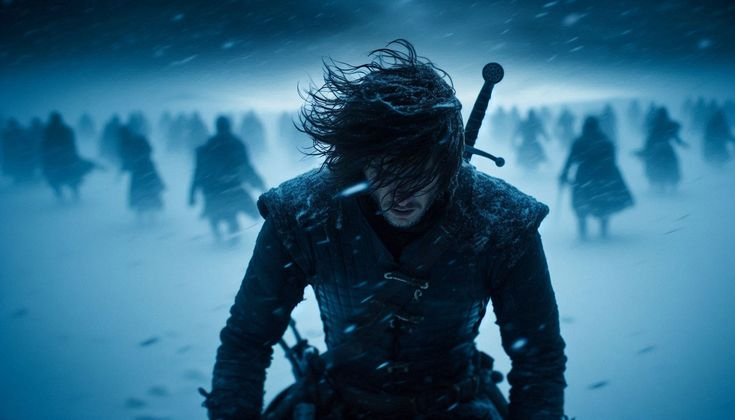

In [4]:
img

In [5]:
# Resize ViT standard size
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image_tensor = transform(img)   # shape → (3, 224, 224)

In [6]:
image_tensor

tensor([[[0.0039, 0.0196, 0.0196,  ..., 0.0039, 0.0078, 0.0118],
         [0.0039, 0.0078, 0.0039,  ..., 0.0000, 0.0078, 0.0118],
         [0.0000, 0.0039, 0.0000,  ..., 0.0000, 0.0039, 0.0078],
         ...,
         [0.0039, 0.0039, 0.0078,  ..., 0.0039, 0.0039, 0.0000],
         [0.0078, 0.0118, 0.0157,  ..., 0.0078, 0.0078, 0.0078],
         [0.0078, 0.0078, 0.0118,  ..., 0.0039, 0.0039, 0.0039]],

        [[0.0941, 0.1333, 0.1490,  ..., 0.0980, 0.0863, 0.0824],
         [0.0902, 0.1137, 0.1255,  ..., 0.0980, 0.0980, 0.0941],
         [0.0706, 0.0941, 0.0980,  ..., 0.1059, 0.1137, 0.1137],
         ...,
         [0.3137, 0.3176, 0.3294,  ..., 0.3765, 0.3725, 0.3725],
         [0.3020, 0.3098, 0.3216,  ..., 0.3804, 0.3725, 0.3686],
         [0.2941, 0.3020, 0.3176,  ..., 0.3765, 0.3725, 0.3647]],

        [[0.1569, 0.2196, 0.2471,  ..., 0.1765, 0.1608, 0.1608],
         [0.1490, 0.1961, 0.2157,  ..., 0.1804, 0.1725, 0.1686],
         [0.1294, 0.1686, 0.1804,  ..., 0.1843, 0.1843, 0.

In [7]:
image_tensor.shape

torch.Size([3, 224, 224])

In [8]:
# Batch dimension add
image_tensor = image_tensor.unsqueeze(0)

In [9]:
image_tensor.shape

torch.Size([1, 3, 224, 224])

In [10]:
patch_size = 16

patches = image_tensor.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)

In [12]:
patches

tensor([[[[[[0.0039, 0.0196, 0.0196,  ..., 0.0039, 0.0078, 0.0039],
            [0.0039, 0.0078, 0.0039,  ..., 0.0118, 0.0118, 0.0118],
            [0.0000, 0.0039, 0.0000,  ..., 0.0078, 0.0078, 0.0039],
            ...,
            [0.0078, 0.0078, 0.0039,  ..., 0.0078, 0.0118, 0.0118],
            [0.0039, 0.0078, 0.0000,  ..., 0.0157, 0.0196, 0.0078],
            [0.0039, 0.0078, 0.0039,  ..., 0.0157, 0.0118, 0.0039]],

           [[0.0078, 0.0118, 0.0118,  ..., 0.0039, 0.0000, 0.0000],
            [0.0078, 0.0078, 0.0078,  ..., 0.0039, 0.0000, 0.0039],
            [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
            ...,
            [0.0078, 0.0039, 0.0000,  ..., 0.0157, 0.0118, 0.0078],
            [0.0000, 0.0000, 0.0000,  ..., 0.0039, 0.0039, 0.0039],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

           [[0.0039, 0.0078, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
            [0.0078, 0.0118, 0.0078,  ..., 0.0000, 0.0000, 0.0000],
          

In [11]:
print(patches.shape)

torch.Size([1, 3, 14, 14, 16, 16])


In [13]:
# Patch Reshape

patches = patches.permute(0, 2, 3, 1, 4, 5)
patches = patches.reshape(1, 196, -1)

In [14]:
print(patches.shape)

torch.Size([1, 196, 768])


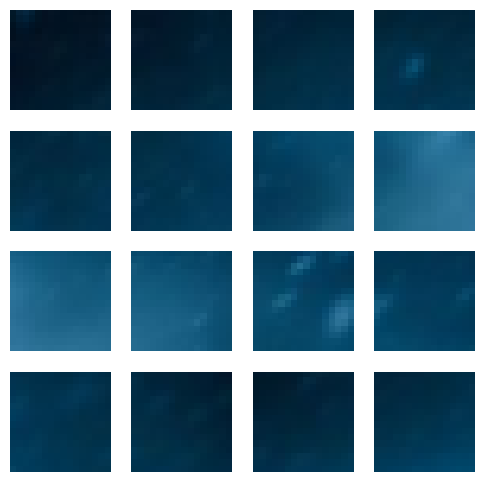

In [15]:
import matplotlib.pyplot as plt

patches_vis = patches.reshape(196, 3, 16, 16)

plt.figure(figsize=(6,6))

for i in range(16):   # first 16 patches
    plt.subplot(4,4,i+1)
    patch = patches_vis[i].permute(1,2,0)
    plt.imshow(patch)
    plt.axis("off")

plt.show()

In [16]:
import matplotlib.pyplot as plt

patches_vis = patches.reshape(196, 3, 16, 16)

def show_patch_group(start_idx):
    
    plt.figure(figsize=(6,6))
    
    for i in range(16):
        plt.subplot(4, 4, i+1)
        
        patch = patches_vis[start_idx + i].permute(1, 2, 0)
        plt.imshow(patch)
        plt.axis("off")
    
    plt.show()

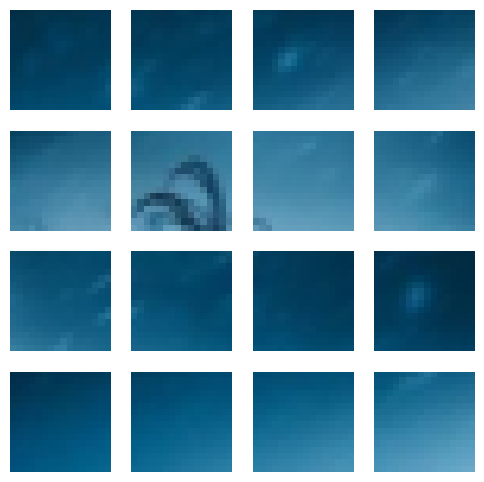

In [21]:
show_patch_group(16)

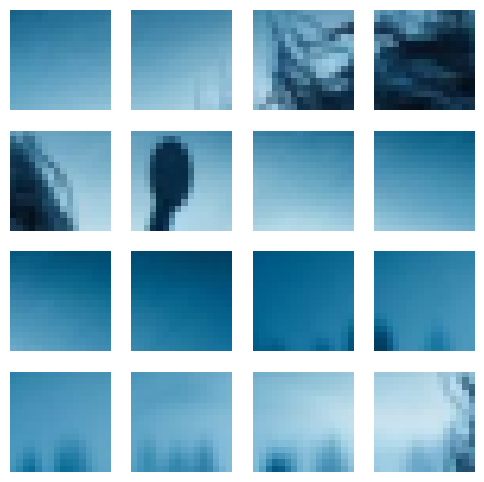

In [22]:
show_patch_group(32)

In [25]:
import matplotlib.pyplot as plt

patches_vis = patches.reshape(196, 3, 16, 16)

def show_side_by_side(start_idx, original_img):

    fig = plt.figure(figsize=(12,6))

    # ----- Original Image -----
    ax1 = fig.add_subplot(1,2,1)
    ax1.imshow(original_img.permute(1,2,0))
    ax1.set_title("Original Image")
    ax1.axis("off")

    # ----- Patch Grid -----
    ax2 = fig.add_subplot(1,2,2)
    ax2.axis("off")
    ax2.set_title(f"Patches {start_idx} to {start_idx+15}")

    grid = plt.GridSpec(4,4, figure=fig, left=0.55, right=0.98, top=0.9, bottom=0.1)

    for i in range(16):
        ax = fig.add_subplot(grid[i])
        patch = patches_vis[start_idx + i].permute(1,2,0)
        ax.imshow(patch)
        ax.axis("off")

    plt.show()

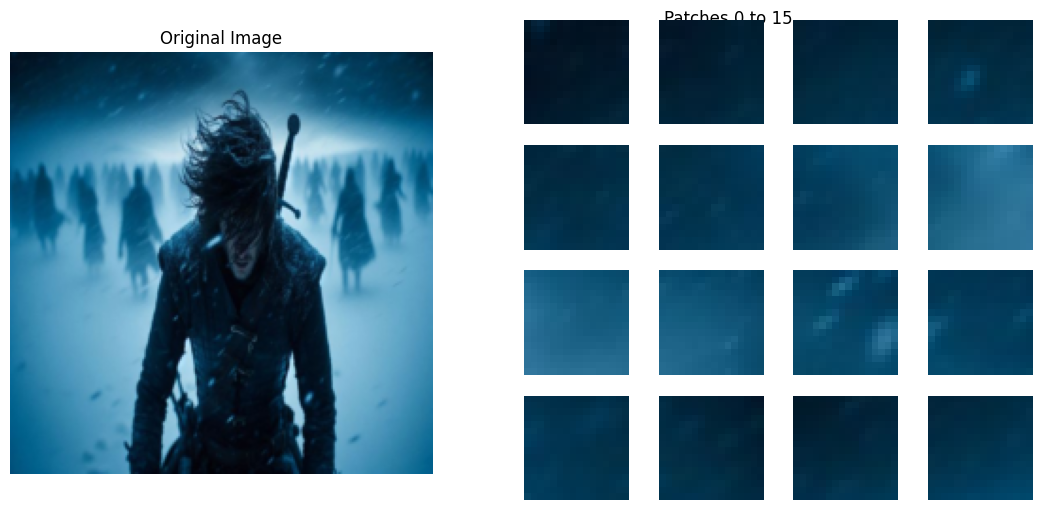

In [26]:
show_side_by_side(0, image_tensor[0])

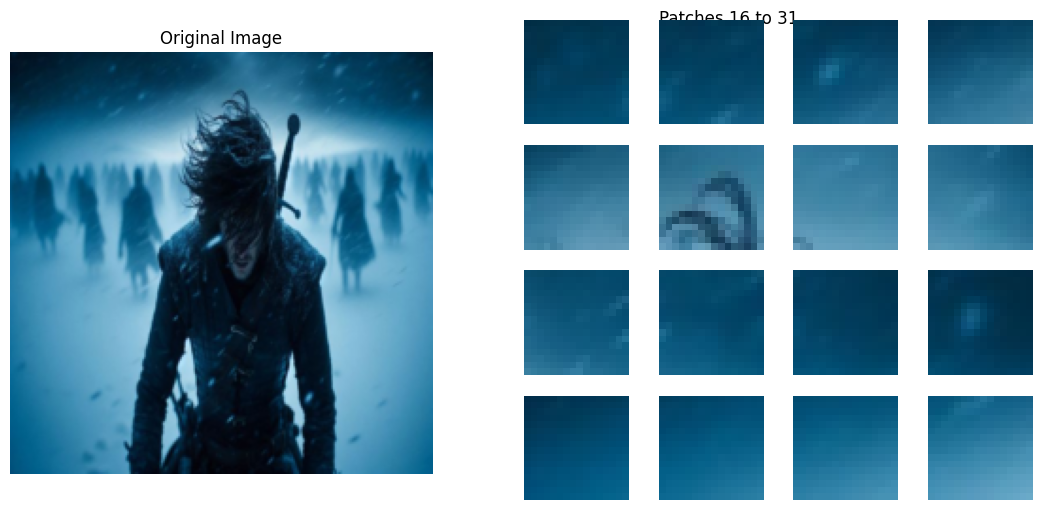

In [27]:
show_side_by_side(16, image_tensor[0])

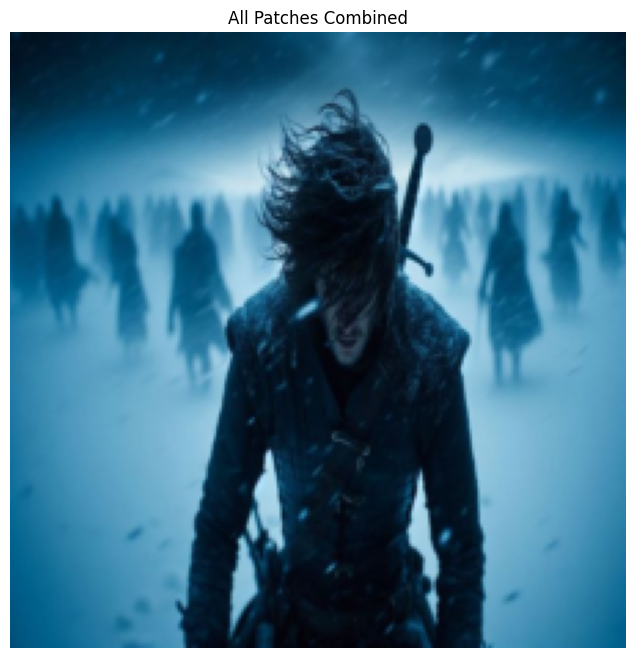

In [29]:
import matplotlib.pyplot as plt
import torch

# patches_vis shape → (196, 3, 16, 16)
patches_vis = patches.reshape(196, 3, 16, 16)

# grid size
grid_size = 14   # 14 × 14 patches

# Empty canvas banate hain
canvas = torch.zeros(3, 224, 224)

patch_idx = 0

for i in range(grid_size):
    for j in range(grid_size):
        
        canvas[:,
               i*16:(i+1)*16,
               j*16:(j+1)*16] = patches_vis[patch_idx]
        
        patch_idx += 1

# Show stitched patches
plt.figure(figsize=(8,8))
plt.imshow(canvas.permute(1,2,0))
plt.axis("off")
plt.title("All Patches Combined")
plt.show()

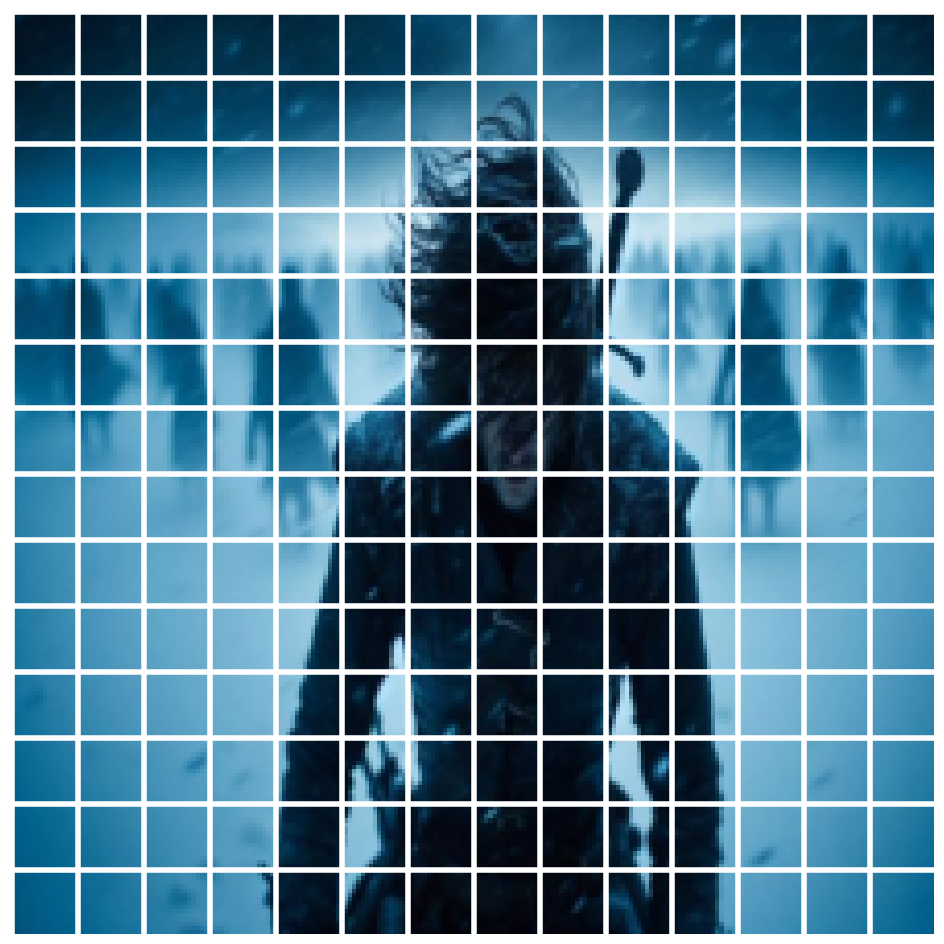

In [37]:
plt.figure(figsize=(12,12))
plt.imshow(canvas.permute(1,2,0))

for i in range(0, 224, 16):
    plt.axhline(i, linewidth=4, c="w")
    plt.axvline(i, linewidth=4, c="w")

plt.axis("off")
plt.show()

In [39]:
# step 2
# Goal >> Vector of length 768
# Total patches: 196 patches
# Final tensor: (1, 196, 768)

In [40]:
patches = patches.reshape(1, 196, -1)

In [41]:
print(patches.shape)

torch.Size([1, 196, 768])


In [42]:
patches

tensor([[[0.0039, 0.0196, 0.0196,  ..., 0.2196, 0.2235, 0.2275],
         [0.0078, 0.0118, 0.0118,  ..., 0.2549, 0.2627, 0.2667],
         [0.0039, 0.0078, 0.0039,  ..., 0.3098, 0.3098, 0.3176],
         ...,
         [0.3804, 0.3647, 0.3412,  ..., 0.6824, 0.6863, 0.6824],
         [0.2824, 0.2784, 0.2745,  ..., 0.6235, 0.6157, 0.6078],
         [0.1647, 0.1608, 0.1569,  ..., 0.5569, 0.5529, 0.5490]]])

In [43]:
patches[0].shape

torch.Size([196, 768])

In [50]:
patches[0]

tensor([[0.0039, 0.0196, 0.0196,  ..., 0.2196, 0.2235, 0.2275],
        [0.0078, 0.0118, 0.0118,  ..., 0.2549, 0.2627, 0.2667],
        [0.0039, 0.0078, 0.0039,  ..., 0.3098, 0.3098, 0.3176],
        ...,
        [0.3804, 0.3647, 0.3412,  ..., 0.6824, 0.6863, 0.6824],
        [0.2824, 0.2784, 0.2745,  ..., 0.6235, 0.6157, 0.6078],
        [0.1647, 0.1608, 0.1569,  ..., 0.5569, 0.5529, 0.5490]])

In [49]:
patches[0][0].shape

torch.Size([768])

In [51]:
patches[0][0]

tensor([0.0039, 0.0196, 0.0196, 0.0078, 0.0039, 0.0118, 0.0157, 0.0078, 0.0000,
        0.0039, 0.0078, 0.0039, 0.0078, 0.0039, 0.0078, 0.0039, 0.0039, 0.0078,
        0.0039, 0.0000, 0.0039, 0.0118, 0.0118, 0.0039, 0.0000, 0.0039, 0.0118,
        0.0118, 0.0157, 0.0118, 0.0118, 0.0118, 0.0000, 0.0039, 0.0000, 0.0000,
        0.0039, 0.0078, 0.0078, 0.0039, 0.0000, 0.0000, 0.0039, 0.0078, 0.0078,
        0.0078, 0.0078, 0.0039, 0.0039, 0.0039, 0.0000, 0.0000, 0.0039, 0.0118,
        0.0078, 0.0039, 0.0000, 0.0000, 0.0039, 0.0118, 0.0118, 0.0118, 0.0118,
        0.0078, 0.0078, 0.0078, 0.0078, 0.0078, 0.0157, 0.0157, 0.0078, 0.0039,
        0.0078, 0.0039, 0.0039, 0.0118, 0.0118, 0.0078, 0.0157, 0.0235, 0.0196,
        0.0157, 0.0118, 0.0157, 0.0196, 0.0157, 0.0157, 0.0196, 0.0118, 0.0039,
        0.0078, 0.0118, 0.0039, 0.0039, 0.0118, 0.0157, 0.0078, 0.0118, 0.0078,
        0.0118, 0.0157, 0.0118, 0.0196, 0.0235, 0.0157, 0.0039, 0.0039, 0.0078,
        0.0078, 0.0078, 0.0078, 0.0039, 

In [52]:
# step 3 Linear Embedding Layer

In [53]:
import torch.nn as nn

embed_dim = 768

linear_embed = nn.Linear(768, embed_dim)

In [54]:
linear_embed

Linear(in_features=768, out_features=768, bias=True)

In [55]:
embedded_patches = linear_embed(patches)

In [56]:
embedded_patches.shape

torch.Size([1, 196, 768])

In [57]:
embedded_patches

tensor([[[ 0.0196, -0.0602,  0.1235,  ..., -0.0446, -0.0169, -0.0695],
         [ 0.0268, -0.0576,  0.1430,  ..., -0.0576, -0.0349, -0.0964],
         [ 0.0372, -0.0767,  0.1728,  ..., -0.0680, -0.0467, -0.1221],
         ...,
         [ 0.2012, -0.3911,  0.6357,  ..., -0.0818, -0.3462, -0.4062],
         [ 0.1710, -0.2953,  0.5224,  ..., -0.0850, -0.2826, -0.3476],
         [ 0.1473, -0.1823,  0.3844,  ..., -0.0831, -0.1919, -0.2984]]],
       grad_fn=<ViewBackward0>)

In [58]:
# Intuition
# Flattened patch: Raw pixels
# Linear embedding: Learned visual features

In [59]:
# Internally

# 768 values
#         ↓
# Multiply by weight matrix
#         ↓
# New feature vector

In [60]:
# Linear projection with Convolutions

In [61]:
import torch.nn as nn

patch_embed = nn.Conv2d(in_channels=3, out_channels=768, kernel_size=16, stride=16)

In [63]:
patch_embed

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

In [64]:
embedded = patch_embed(image_tensor)

In [65]:
embedded.shape

torch.Size([1, 768, 14, 14])

In [66]:
embedded

tensor([[[[-0.0591, -0.0704, -0.0875,  ..., -0.1147, -0.0920, -0.0810],
          [-0.0832, -0.1134, -0.1322,  ..., -0.1629, -0.1268, -0.1235],
          [-0.1623, -0.1756, -0.1898,  ..., -0.2661, -0.2358, -0.2029],
          ...,
          [-0.1611, -0.2083, -0.2674,  ..., -0.3025, -0.2708, -0.2333],
          [-0.1469, -0.1814, -0.2187,  ..., -0.2780, -0.2527, -0.2088],
          [-0.1455, -0.1693, -0.1806,  ..., -0.2650, -0.2216, -0.1901]],

         [[-0.0654, -0.0810, -0.0873,  ..., -0.1095, -0.1019, -0.1073],
          [-0.0969, -0.1065, -0.1265,  ..., -0.1653, -0.1313, -0.1133],
          [-0.1425, -0.1753, -0.2357,  ..., -0.4149, -0.3195, -0.2240],
          ...,
          [-0.1582, -0.2619, -0.4013,  ..., -0.4850, -0.4025, -0.3013],
          [-0.1226, -0.2142, -0.3082,  ..., -0.4167, -0.3515, -0.2447],
          [-0.1117, -0.1709, -0.2827,  ..., -0.3661, -0.2916, -0.1877]],

         [[-0.0633, -0.0761, -0.0897,  ..., -0.1202, -0.1190, -0.1193],
          [-0.0974, -0.1009, -

In [67]:
embedded = embedded.flatten(2)

In [68]:
embedded.shape

torch.Size([1, 768, 196])

In [69]:
embedded = embedded.transpose(1, 2)

In [70]:
embedded.shape

torch.Size([1, 196, 768])

In [71]:
# Conv2D yaha kya kar raha hai:

# 👉 Har 16×16 region pe filter apply
# 👉 Filter learn karta hai feature projection
# 👉 Stride ensure karta hai overlapping nahi ho

In [72]:
# Now adding CLS Token

In [73]:
# CLS Token Shape: (1, 1, 768)
# 1 token
# 1 embedding vector

In [81]:
cls_token = torch.zeros(1, 1, embed_dim)
cls_token.shape

torch.Size([1, 1, 768])

In [82]:
cls_token

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [78]:
embedded.shape[0]

1

In [84]:
B = embedded.shape[0]
B

1

In [85]:
embed_dim = embedded.shape[2]
embed_dim

768

In [86]:
cls_token = torch.zeros(1, 1, embed_dim)
cls_token.shape

torch.Size([1, 1, 768])

In [87]:
cls_tokens = cls_token.expand(B, -1, -1)
cls_tokens.shape

torch.Size([1, 1, 768])

In [88]:
embedded = torch.cat((cls_tokens, embedded), dim=1)
embedded

tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [-0.0591, -0.0654, -0.0633,  ..., -0.0482, -0.0664, -0.0029],
         [-0.0704, -0.0810, -0.0761,  ..., -0.0732, -0.0727,  0.0128],
         ...,
         [-0.2650, -0.3661, -0.1540,  ..., -0.3519, -0.1415, -0.1407],
         [-0.2216, -0.2916, -0.1565,  ..., -0.3555, -0.1275, -0.0890],
         [-0.1901, -0.1877, -0.1678,  ..., -0.3470, -0.1130, -0.0239]]],
       grad_fn=<CatBackward0>)

In [89]:
embedded.shape

torch.Size([1, 197, 768])

In [90]:
from masked_mha import Masked_MHA